# Imports & Data

In [66]:
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb
import numpy as np
import pandas as pd
import torch

fname = '/Library/Fonts/IBM_Plex_Sans/static/IBMPlexSans-Regular.ttf'  # download IBM Plex Sans
font_manager.fontManager.addfont(fname)
prop = font_manager.FontProperties(fname=fname)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
    'lines.linewidth': 2,
    'lines.markersize': 5,
})

plt.rcParams['figure.figsize'] = (10, 6)  # 8x6 inches

ROOT_DIR = '/Users/BLU/Library/CloudStorage/Box-Box/ACT/00_General/Collaboration/Master_Thesis/Nazar_Risk_Maps/final_notebooks'

# Blue, Purple60, Gray70
colors = ['#0F62FE', "#8A3FFC", "#525252"]

In [67]:
# STANDARD. NO SUBSAMPLING. The number of images is 3*number of timestamps.
# mIoU per 1,2,3,4,... used timestamps
pastis_values_tf_base_tds = [0.1777, 0.3669, 0.4814, 0.477, 0.4925, 0.5343, 0.5233, 0.5508, 0.5558, 0.5477, 0.5631, 0.5651, 0.5735, 0.5613, 0.5622, 0.5669]
pastis_values_tf_base_rs = [0.1799, 0.3815, 0.5028, 0.4872, 0.5231, 0.563, 0.5413, 0.5651, 0.58, 0.5654, 0.5781, 0.5852, 0.5973, 0.579, 0.5789, 0.5882]
pastis_values_tm_base = [0.1725, 0.3391, 0.4811, 0.4382, 0.4542, 0.5373, 0.5029, 0.5452, 0.5487, 0.5473, 0.5632, 0.5585, 0.5763, 0.5553, 0.5583, 0.5569]
# RMSE per 1,2,3,4,... used timestamps
biomassters_values_tf_base_tds = [0.17453, 0.17124, 0.169009, 0.165373, 0.161056, 0.160405, 0.159392, 0.15854, 0.148873, 0.143682, 0.143904, 0.139373]
biomassters_values_tf_base_rs = [0.17445, 0.170354, 0.166948, 0.164499, 0.160783, 0.160512, 0.158567, 0.15848, 0.148973, 0.144391, 0.143501, 0.137454]
biomassters_values_tm_base  = [0.192495, 0.184113, 0.176856, 0.173342, 0.167636, 0.16483, 0.163818, 0.162992, 0.155341, 0.151149, 0.150071, 0.145519]

# SUBSAMPLING STRATEGIES
pastis_number_images = [1, 2, 4, 8, 16, 32, 48]
pastis_tf_base_tds_subsample_testsubsample = [0.3239, 0.3883, 0.4482, 0.5064, 0.5353, 0.5606, 0.5669]
pastis_tf_base_tds_subsample = [0.4055, 0.4569, 0.5217, 0.5395, 0.5660, 0.5711, 0.5669] # Sample tokens inside images
pastis_tf_base_tds_subimages = [0.1442, 0.3159, 0.4095, 0.4615, 0.5226, 0.5567, 0.5669] # Sample full images
pastis_tf_base_tds_subimages_testsubsample = [0.1416, 0.2058, 0.3036, 0.3921, 0.4676, 0.5341, 0.5669]
biomassters_number_images = [1, 2, 4, 8, 12, 24, 36]
biomassters_tf_base_tds_subsample_testsubsample = [0.17726, 0.16175, 0.152636, 0.14568, 0.142775, 0.139245, 0.139373]
biomassters_tf_base_tds_subsample = [0.162244, 0.146384, 0.142044, 0.137981, 0.13732, 0.137882, 0.139373]
biomassters_tf_base_tds_subimages = [0.182236, 0.158367, 0.150154, 0.143367, 0.139626, 0.138198, 0.139373]
biomassters_tf_base_tds_subimages_testsubsample = [0.19224, 0.177033, 0.162154, 0.151056, 0.146122, 0.140836, 0.139373]


In [149]:
# All for TerraFlod-Base-TDS
# STANDARD
# [i,j] i indexes number of timesteps used, j indexes epoch (out of 50).
pastis_standard_times = np.array([
    [92.89993358, 90.21438193, 85.91483426, 95.28185344, 86.28069997, 84.76332736, 94.57113934, 82.14385247, 85.69360399, 83.48454118, 93.8596766, 88.03488064, 67.53287315, 87.26207852, 92.04435539, 68.44991469, 66.91051984, 68.01997495, 64.99539328, 71.10590553, 69.4335506, 66.18135023, 70.2159996, 95.79039454, 64.23418355, 63.27048159, 64.95522213, 63.31127429, 64.9020052, 70.85367036, 68.30455923, 72.36364198, 70.94013977, 67.60477591, 71.80027461, 62.50464725, 74.02825046, 70.18145275, 74.31485176, 73.59395409, 70.59970784, 65.13743639, 70.95931697, 71.54844403, 69.02977133, 63.10624337, 58.19026613, 63.60093403, 67.17132378, 66.71211052],
    [87.477319, 87.99641585, 88.15399003, 84.19591069, 85.89600682, 90.03183675, 88.09705019, 91.46630025, 75.88760829, 84.18865252, 67.30719113, 102.89156914, 95.47691441, 82.57921624, 76.2089622, 77.36082768, 61.69661736, 98.81763959, 95.27593398, 68.01427484, 87.77132344, 61.99640083, 60.75802898, 82.36488008, 68.65099001, 88.35033989, 72.58749151, 69.24046803, 64.74841309, 64.59636354, 68.04930854, 65.87352562, 69.52064371, 74.71604729, 54.99670672, 88.8396101, 51.80110407, 60.76965165, 66.617208, 66.39536953, 64.91395688, 60.24038291, 65.2099247, 68.08061004, 55.42719746, 70.52038717, 65.61760163, 59.33299828, 60.63251781, 59.5019865],
    [87.79827762, 87.95357513, 87.92154527, 83.58207655, 86.26147318, 89.36356902, 87.63928032, 67.60559988, 99.20488143, 85.84540892, 99.66003585, 86.60267067, 83.90572357, 83.35228395, 80.66731739, 66.87580824, 92.48337746, 90.64558363, 68.96781683, 70.4104259, 70.13708472, 78.09065032, 69.76635861, 70.23495626, 75.02815032, 83.09049463, 73.63287187, 71.53177238, 67.5053947, 66.49937129, 69.465909, 67.60854459, 96.50807047, 73.68745303, 72.79213333, 77.56429267, 70.60831428, 68.43957162, 69.73019123, 66.43860769, 67.68260908, 94.56011081, 76.37287855, 70.53141308, 71.30344915, 70.17859077, 69.56600475, 90.12272072, 68.5391562, 70.86210942],
    [145.97607541, 139.07421255, 141.83351016, 140.35356927, 142.43756962, 142.78682375, 142.88135552, 146.01854587, 142.17795157, 145.54633594, 140.16795778, 141.77254224, 114.06432438, 146.07592607, 141.22688842, 141.29766989, 109.27839804, 144.44609737, 144.6834867, 115.87046957, 112.49195337, 144.12614369, 149.63718843, 142.39246464, 113.99022412, 138.19257092, 146.88408208, 114.11941147, 116.43585515, 110.66186881, 113.28882074, 115.09341812, 118.62150502, 119.06644201, 113.66261339, 112.44024825, 140.21450973, 108.93516278, 113.95460796, 112.41272712, 113.43046761, 113.43729663, 113.50097823, 115.20133686, 111.17705965, 136.89874601, 114.52619386, 111.53269911, 114.99716282, 112.02813673],
    [141.85851479, 140.55565882, 134.69224334, 135.30812621, 141.46485996, 136.05703855, 122.24936295, 107.48243308, 130.01155639, 129.16838264, 136.62922812, 135.89270282, 135.2820127, 128.37045097, 133.23755288, 128.46329403, 136.84467387, 100.17634511, 136.26329875, 100.73762107, 136.01204371, 135.95657563, 109.96727133, 101.45270944, 103.89689922, 121.98523068, 111.56609797, 137.77496958, 145.19857001, 99.58966684, 104.93519831, 107.44307232, 115.96705151, 99.76078486, 138.72212672, 131.45897937, 100.05112267, 109.68960142, 104.23175597, 101.46975446, 102.89700675, 107.18373799, 100.12115693, 100.12704325, 109.8918705, 110.85386276, 102.6929245, 108.7768538, 104.77360773, 109.48409677],
    [153.75016379, 147.61481905, 160.38044071, 164.11879396, 155.094733, 158.78609943, 159.2634213, 120.16114068, 144.85985899, 120.41267562, 145.13198376, 143.77302957, 152.55398297, 126.3493185, 150.71896958, 156.01117563, 118.71941805, 121.78335762, 144.24847293, 146.78868079, 120.05858016, 147.95938301, 153.05919623, 123.29579592, 127.12999177, 129.66005087, 151.92023516, 116.62311983, 157.5687592, 128.32655001, 118.36546755, 127.38805842, 122.5633204, 115.82262301, 117.76085043, 116.85780764, 124.98117352, 128.97900558, 121.85198569, 118.89077592, 118.90075994, 119.21593451, 117.34929729, 129.06056929, 118.96605587, 125.844486, 119.21941829, 123.41580677, 122.93970442, 126.79597354],
    [173.35307097, 181.79194689, 182.50943112, 166.87628889, 175.58191514, 168.8597331, 166.42199969, 170.72540188, 158.74222612, 149.02885151, 172.07601333, 172.75951195, 176.63965654, 171.8205924, 163.94298172, 144.27946663, 135.81864405, 138.09905529, 160.80217123, 137.51202273, 192.98778057, 187.44531751, 162.59625793, 166.92622662, 141.69311833, 175.11720586, 130.50620389, 131.27342963, 139.29877567, 174.73712897, 133.88411283, 133.80202055, 145.45890212, 139.95923257, 134.00060558, 134.17043877, 170.32785082, 137.22514892, 141.38621473, 141.46466088, 166.63686585, 137.84068012, 133.97289085, 140.78335881, 140.03378773, 180.30443954, 137.59030986, 133.73092175, 141.45968866, 145.03708339],
    [184.75778484, 183.96361732, 186.748734, 205.62578869, 195.65090203, 194.37715435, 197.72639918, 194.60437202, 199.6671133, 199.31900048, 195.57971454, 194.37393284, 199.13786817, 204.036484, 198.42206359, 191.91828823, 151.32755303, 195.37264228, 197.49220562, 164.38114285, 186.32958174, 195.25224829, 151.93698382, 199.7297442, 154.00046659, 158.11825728, 194.19054675, 154.14276624, 194.24849558, 156.17585278, 165.21060276, 193.01467395, 149.88307452, 154.38234401, 155.1223619, 154.07024789, 153.19831467, 160.46787357, 152.55760145, 166.67346883, 150.46726918, 151.85432243, 158.23107696, 152.39527321, 156.54724145, 163.17629719, 158.54506135, 159.94269705, 154.58175802, 150.50109172],
    [215.57004166, 234.57525992, 227.3441453, 223.67995858, 221.31429434, 227.28249049, 229.20270181, 178.14187622, 225.28387618, 233.92996669, 228.09871936, 219.31123781, 224.20957756, 233.94407415, 174.70868707, 264.78476143, 220.06052446, 222.7064414, 218.90316081, 179.91810465, 180.75581551, 225.97864914, 181.07415199, 173.57918286, 178.69132185, 180.2666328, 172.39318871, 186.35486221, 228.48676658, 176.76648951, 186.01411057, 232.16675401, 178.39485335, 173.07024193, 181.13394403, 179.98471832, 174.11718154, 180.91525722, 175.84140182, 178.14126587, 233.65901446, 178.68117905, 179.13440561, 178.44855475, 178.23493028, 191.76546407, 178.59309244, 179.15492988, 179.62900972, 178.84952545],
    [271.21842098, 267.934232, 266.51905084, 254.22647214, 269.25606775, 256.44927239, 266.56404209, 272.56579566, 266.34143925, 257.17398238, 258.69516516, 265.37084103, 262.282547, 266.77073407, 269.56059408, 276.2491014, 256.11917996, 261.81624675, 205.60278678, 215.56882191, 266.9291482, 204.58716083, 206.98315001, 204.82642365, 209.1234169, 203.39611864, 262.99650168, 257.82638621, 271.69972515, 201.27250886, 205.51829481, 269.37976241, 204.2555244, 211.38905692, 207.39004374, 266.16956377, 204.02768588, 206.5556283, 209.30292296, 203.5211041, 206.85953593, 363.42532659, 210.85904527, 207.93014073, 208.76808786, 204.06264353, 270.17076159, 206.47797537, 207.71993637, 205.69589329],
    [291.92535615, 297.61817622, 293.03802896, 286.88412499, 296.19689155, 290.61016178, 290.03708434, 298.43753695, 297.64190054, 289.92082357, 294.11633635, 304.00186491, 234.27717781, 302.97458863, 296.93923783, 240.49346089, 225.89414525, 295.13139367, 296.02215385, 227.00407934, 230.57989144, 224.47956252, 227.30715275, 230.22499228, 228.21710634, 227.05675936, 231.63515234, 232.08641815, 227.95053887, 226.38670707, 299.32681751, 293.08502007, 226.9730289, 228.71901011, 230.98112321, 226.89019704, 228.88850951, 229.63978267, 351.46745872, 235.47514248, 225.8938117, 225.65679502, 226.5913825, 226.84355235, 226.69363976, 225.07581306, 223.65516233, 228.34786057, 225.62957692, 225.31283951],
    [323.52453446, 329.27367282, 330.20894337, 324.17252755, 316.06215072, 316.84970927, 320.36224675, 326.94188666, 321.5071733, 325.91975522, 352.32752371, 326.36906242, 331.10958552, 318.47245312, 330.50230217, 326.92049265, 332.3846221, 249.14147615, 316.80471539, 250.32814527, 328.94480538, 325.56760287, 251.8426199, 249.11775398, 248.63495493, 326.88629532, 252.05747843, 326.40537071, 253.05335641, 249.40613365, 251.83339643, 250.83627176, 251.49859571, 246.79675817, 291.76944447, 249.800946, 255.29442763, 322.63275099, 250.50013566, 252.80814171, 248.4935534, 248.16389012, 248.01107025, 250.20421338, 246.55670547, 249.64134669, 249.42866921, 253.78259516, 246.24333763, 250.08861399],
    [362.02924633, 363.82117653, 362.97248673, 358.23284602, 359.8075819, 356.57437491, 358.20266747, 280.87701678, 354.13013649, 276.46185112, 369.28398609, 365.89478946, 361.42301512, 283.84668517, 353.69634271, 361.72382951, 276.44149375, 353.18345237, 357.25686955, 280.67934036, 281.58025813, 276.69550562, 358.90583706, 285.63048291, 281.8524003, 275.89181757, 354.27206588, 362.2962935, 280.10668826, 278.79752278, 313.43189049, 318.63857627, 275.87845039, 276.72431755, 274.92141294, 285.2659142, 277.16350675, 276.52179313, 276.91212273, 278.05197549, 277.4645505, 274.3901701, 276.60345745, 351.53655982, 277.68209696, 273.86419272, 275.67313361, 273.59440494, 274.45332289, 349.91807079],
    [400.45384026, 396.90872502, 389.03216076, 388.08188629, 390.35840726, 387.75539112, 390.61625504, 384.80589008, 383.18756604, 389.33074093, 384.28813815, 394.05394268, 298.83499551, 391.33495617, 387.89304233, 388.81160212, 302.24244523, 385.94948006, 299.04659557, 298.95077515, 386.53092504, 391.88573742, 300.06881857, 304.04687858, 391.83898425, 389.81378698, 297.21637988, 298.94640899, 340.58578634, 299.79373193, 299.74814701, 300.17603803, 386.04751325, 299.0524385, 381.75539637, 296.53261089, 298.65432501, 381.62461591, 299.61719608, 383.37256098, 297.80568218, 293.52341843, 294.26757526, 292.02352023, 297.51947498, 386.06811786, 383.64471722, 297.11226821, 293.72784281, 294.15377021],
    [440.77445936, 416.36230016, 426.36964655, 425.01388025, 428.55052066, 417.23009586, 419.05879545, 323.0533483, 426.11835313, 435.04959631, 419.4400382, 429.64578748, 422.67491174, 427.07382298, 428.41718388, 422.08790278, 422.09394622, 424.34090781, 424.13776326, 331.80030274, 327.97972202, 327.33059382, 329.49715614, 331.7775352, 326.23795247, 376.44647098, 329.49839568, 327.81749368, 424.82892823, 323.67993689, 324.42778563, 424.38083816, 325.09151745, 323.22864151, 325.87528491, 324.05526876, 419.29149222, 322.93956661, 324.60003185, 324.62406611, 325.03930092, 324.05189419, 325.62808013, 325.63728976, 323.78250837, 324.54075694, 323.89379907, 324.60216761, 326.23527765, 329.43049121],
    [459.73505998, 454.16608858, 454.34963846, 454.92202568, 455.99808073, 452.70971727, 452.42256784, 451.53307319, 456.63414121, 456.011765, 449.57177687, 452.18527079, 466.1480391, 456.81365561, 457.41266584, 461.33714128, 460.18334746, 347.09586239, 452.80662346, 346.70278716, 459.70929289, 460.46544194, 350.49119306, 501.07116938, 355.06242228, 461.16558313, 460.91998982, 354.40067172, 458.58010554, 360.22336245, 352.78221512, 353.3244648, 356.72023416, 361.50767732, 355.23823118, 360.57175231, 488.83573627, 355.17619705, 351.69365859, 353.19997931, 353.68223119, 353.24430394, 352.80093479, 355.11426115, 354.29894638, 353.96756053, 354.96203947, 354.05092478, 358.18877554, 367.88116789]
])

biomassters_standard_times =  np.array([
    [222.64311934, 211.19381857, 176.77368069, 168.94934344, 174.91133547, 122.93358493, 168.35665536, 134.21588135, 179.73051977, 208.1957922, 271.02957678, 316.66250229, 273.00132298, 328.90311146, 300.51980615, 231.08178949, 254.38530612, 248.94278669, 225.64354253, 288.83895636, 310.29635072, 253.81760621, 228.56101537, 232.09314919, 251.89961243, 213.19114876, 239.95835352, 232.46598577, 181.19048214, 235.34414506, 189.9025135, 217.45256495, 221.68957114, 278.32420421, 206.97422314, 216.51758647, 222.05117083, 179.40320349, 219.30337381, 208.74609494, 210.8721509, 191.77226233, 292.09017467, 240.39287448, 190.58301926, 222.28380466, 226.92569184, 215.71593833, 203.7153945, 205.82174492],
    [249.05776405, 252.41048002, 254.44341803, 263.58808398, 176.08734393, 239.41014481, 245.61128783, 245.59599233, 181.70744443, 171.03048253, 182.28754258, 246.89688134, 187.93369842, 230.6665957, 174.2433672, 185.96511102, 181.20082307, 184.4728303, 174.38987017, 170.87334967, 233.5639596, 177.0990665, 172.22135258, 218.05631876, 172.39308214, 167.00603271, 167.16364861, 189.00321841, 170.69415903, 178.28693652, 161.75176549, 236.50216269, 169.64199352, 156.12334824, 221.29516363, 168.24263525, 165.14243817, 168.93830991, 155.37258267, 166.41306496, 163.03606033, 156.15493035, 161.80071712, 162.34320426, 157.73724651, 171.88059568, 151.85435009, 162.71415567, 169.22605896, 154.83608913],
    [233.11184573, 251.02200818, 238.98513126, 266.02487683, 197.87571096, 271.34338999, 269.02563953, 269.1475184, 179.68505907, 260.87644267, 269.23717785, 277.23661518, 239.44965935, 180.67549253, 218.42385101, 211.14198089, 223.97327757, 257.87208748, 231.50541568, 262.74379754, 221.50935102, 191.01779628, 194.51397228, 197.61339283, 176.27210689, 297.16409421, 228.64948678, 172.72626424, 248.62614322, 198.02512336, 261.10421705, 207.97008419, 185.38387179, 253.45994902, 207.15005589, 222.48066473, 188.07713675, 209.55937815, 218.00711918, 255.36692023, 209.07349253, 218.57935333, 208.02316856, 214.20877051, 187.63782787, 249.98869491, 192.82456136, 215.64153719, 209.39871287, 181.12225842],
    [297.1967895, 285.23847747, 287.70621729, 286.63516188, 284.82308483, 231.68329525, 287.7052424, 289.89716101, 233.31467509, 289.27838182, 288.7250011, 289.00088716, 285.84477472, 289.0884347, 236.34279656, 229.7992146, 287.23815274, 291.06045389, 234.75245094, 231.64258146, 236.80661869, 233.58103704, 233.01136804, 235.95129156, 288.45045805, 293.13564539, 293.30173469, 236.70518899, 235.11119175, 292.12708688, 290.55443859, 238.14011431, 236.60991001, 293.62220454, 238.67944217, 237.03227615, 235.55033922, 237.46437073, 234.98512912, 235.85914397, 235.68111491, 234.93487525, 238.86148334, 235.01857376, 234.41718745, 236.77226949, 233.46976495, 234.26976037, 234.8788228, 237.14520192],
    [382.2149725, 378.37827659, 381.17096281, 377.40631866, 382.63566422, 381.95377302, 392.63983774, 391.58535719, 401.51276231, 391.38593602, 390.49971604, 310.26766753, 311.93115807, 308.52655721, 325.52180886, 401.36008048, 312.05368209, 310.00009084, 312.90230322, 400.07583046, 316.03930783, 325.49237108, 409.02213049, 311.61379671, 316.31907916, 372.54236126, 366.25705957, 366.40960264, 297.26409674, 298.22718573, 295.26388168, 293.90074468, 293.74247503, 292.38718534, 364.35097742, 293.61560369, 295.19638562, 293.61347747, 364.02134085, 299.00813246, 368.70832372, 306.7430079, 297.38272834, 364.45771289, 297.75920081, 298.63362932, 293.68196011, 295.62592912, 292.71766257, 298.14866018],
    [490.56988764, 487.49152184, 468.87441897, 473.04282045, 389.16343379, 394.00672364, 464.15273094, 482.19308591, 498.05651164, 505.49577928, 502.58787394, 400.79460239, 384.30632496, 506.80166793, 487.0577333, 474.29008913, 366.74021268, 492.02445555, 491.42067027, 498.89057517, 385.35759258, 391.88029981, 521.41257572, 497.19470906, 377.65132022, 364.61111164, 365.68445873, 365.69296217, 374.00737667, 364.07858133, 456.77950788, 452.92447257, 359.83646655, 364.8896246, 361.1794548, 361.22592211, 454.31220651, 456.69664025, 362.69680977, 451.77360296, 363.30113697, 364.81106615, 360.79947233, 363.93678164, 361.44688964, 450.54769349, 362.68652248, 361.23561049, 361.9239583, 362.08089471],
    [548.71513081, 565.30117226, 574.08190608, 582.13107204, 580.69581485, 455.79167104, 579.79586744, 591.42683816, 449.5129621, 585.26339698, 574.12522435, 569.39986777, 590.83661914, 595.23810315, 468.70900512, 574.62782073, 465.24677777, 583.86546969, 600.69684696, 455.34343052, 447.12381148, 447.18481708, 553.98477435, 555.18067336, 442.60026479, 443.35749102, 445.77147627, 445.37446356, 444.46185756, 551.49838567, 552.52587724, 440.92796397, 437.64009714, 438.14397407, 441.78810811, 439.68521094, 548.57203627, 440.64249802, 445.75351, 439.33601236, 437.83386993, 436.75760245, 435.23524451, 435.17311859, 433.31753206, 436.15460563, 436.13837481, 433.3145411, 434.20047855, 431.49055433],
    [675.34049058, 670.63987827, 666.04086971, 664.96885824, 672.60222793, 538.28257465, 543.73428011, 673.1586144, 539.49767017, 670.29996133, 538.58098483, 674.33917856, 540.51087785, 542.02097392, 545.11139107, 673.93822908, 675.14058852, 689.88300705, 528.21294737, 681.35426092, 672.69332433, 675.81723166, 535.28166676, 534.09849024, 536.92497492, 535.2337544, 533.22872138, 538.03726268, 530.85892057, 533.33468795, 660.76730418, 530.28985667, 528.74237323, 529.89816475, 660.68593025, 659.02616, 530.31104088, 533.66952133, 528.40018988, 529.01367092, 529.47736788, 526.97620201, 527.76721144, 526.14899206, 528.95879221, 525.0456903, 526.98217869, 527.76393437, 526.34736419, 659.9080987],
    [782.94459987, 785.73815894, 621.17922902, 789.67295718, 781.29575276, 618.995296, 785.48756075, 781.61702657, 622.235322, 786.08127666, 791.4126513, 788.81516075, 628.83785939, 789.01424885, 782.78559113, 778.82390308, 624.09005165, 781.71222782, 617.98331738, 620.5941186, 629.78289485, 625.32553673, 773.82613444, 617.81329179, 773.44826174, 771.4696424, 618.66946793, 617.58582997, 615.16191959, 614.8036654, 772.0178628, 617.40061975, 615.86289978, 616.70494819, 774.67479753, 613.83949685, 613.47047877, 616.39568663, 613.7387073, 615.47398353, 615.69840479, 613.6394372, 768.17579699, 766.89881825, 613.15194559, 613.48145223, 612.38198543, 613.29451013, 614.05926275, 611.7172153],
    [892.80506563, 887.25868487, 894.24955916, 891.89681506, 891.7487278, 901.33247685, 896.34068203, 895.64840651, 717.79018784, 707.42764711, 892.59214282, 904.58058786, 724.90257549, 711.3024466, 897.26005006, 895.54087353, 901.64394975, 709.19035602, 896.68703794, 898.67293048, 709.28470302, 711.08831835, 899.03787112, 711.38336802, 709.95849252, 896.45981765, 710.56500649, 894.87975907, 712.25602531, 906.32127929, 715.91632271, 904.76437163, 713.46875119, 713.85488939, 712.3656466, 720.50734544, 715.86631823, 902.41318393, 718.55548811, 898.27359939, 901.14683175, 711.57142615, 713.93029141, 715.18165255, 719.36953664, 711.39748979, 715.16543961, 716.33438468, 713.53997517, 713.15002275],
    [1027.73569298, 1028.3676157, 1032.77427244, 1032.16291785, 1047.20798635, 1034.66770697, 1032.72913527, 1029.4261291, 817.00412488, 1036.02603841, 819.91207576, 1041.14219427, 822.01845956, 820.42310238, 1033.28903317, 1032.18393755, 817.24683595, 820.67712903, 817.38743091, 1033.98013926, 1038.11146855, 813.61763024, 819.14492607, 816.30827427, 1033.24772024, 1036.92841172, 1035.80954766, 1040.39719677, 817.73912549, 1032.77159262, 818.28808928, 813.65350223, 817.4579401, 820.07966161, 1036.73499179, 816.00821328, 815.61161423, 819.33350205, 819.81609964, 817.79300332, 816.97933602, 1032.06406093, 1043.88845992, 812.42369699, 808.15147543, 810.57965946, 811.03079247, 807.32544231, 811.73071027, 1028.9068625],
    [1169.45927572, 1170.83607793, 1174.00310731, 1181.54149079, 1175.29885864, 929.84597206, 931.69846201, 1184.02913594, 931.26526165, 1187.23235679, 1185.64994717, 1183.04580736, 941.40602756, 936.76092982, 1179.78332758, 1182.63314104, 1175.66213536, 1188.25569606, 1186.09518576, 1181.27808452, 937.29625058, 1193.7702744, 936.36502361, 935.62407041, 1195.27230573, 938.68718314, 934.41784954, 935.66401076, 936.91012669, 1186.84553123, 934.49863219, 936.17101693, 941.32075262, 1187.49754667, 945.99554706, 934.52553678, 937.13973212, 934.48965073, 926.2244451, 935.17880177, 929.24317575, 926.75935698, 929.71102476, 937.72817612, 925.0286622, 922.60833669, 921.46831489, 920.67790079, 922.98706555, 921.66199231],
])

# SUBSAMPLING
# [i,j] i indexes number of images used in the subsampling: 1, 2, 4, 8, 16, 32, 48
pastis_subsample_times = np.array([
    [238.95228577, 260.89970255, 256.70493388, 253.73335528, 260.56343937, 252.77564692, 242.98853064, 221.40980005, 246.15325952, 237.0909183, 261.00592875, 245.02547073, 243.75349069, 131.86504745, 247.05120254, 261.38821459, 145.65302086, 109.78897214, 211.8227849, 212.29126549, 104.74211049, 207.7776494, 213.64418435, 216.46169877, 112.35901785, 102.79671478, 107.61520028, 118.45390892, 104.22302914, 205.05580401, 102.43372345, 103.29157615, 104.49682236, 213.0330441, 205.93433142, 208.81241798, 219.62213993, 208.40508175, 109.19424534, 102.98524904, 106.45336699, 114.15969658, 108.24638319, 104.20456648, 112.58662558, 104.8795979, 104.2551949, 111.37563467, 104.78936744, 109.91848993],
    [222.99620914, 223.17269754, 216.11940837, 224.66713977, 224.21946216, 224.26439261, 224.63086271, 112.12509704, 217.26261544, 216.97858953, 223.37595701, 111.0379138, 222.59847713, 113.21670246, 217.99850225, 112.15878034, 212.92760253, 113.73733282, 115.37229252, 216.63415456, 217.11232972, 117.17114282, 217.53787374, 219.8168323, 217.14522719, 110.61787033, 214.85363054, 216.81480336, 215.15989637, 219.62948823, 215.67396307, 116.65385389, 215.16288614, 110.51564574, 214.80521107, 107.84098577, 214.51490116, 214.56058741, 112.07818103, 114.20834184, 108.11140895, 108.36845756, 113.72848773, 109.01380205, 109.61064625, 111.64731407, 112.27110744, 110.41194391, 112.45164585, 108.37434411],
    [232.82197952, 225.96507478, 228.08511925, 230.0882628, 228.01150012, 228.08178473, 226.2295258, 223.51539564, 223.64014626, 227.2329967, 225.81564951, 230.66139412, 116.79592919, 218.43240309, 224.52888751, 220.96998, 113.63893461, 226.41858792, 223.42696404, 225.43975234, 220.03187251, 114.67021799, 218.88307381, 113.98105001, 223.96605539, 125.57510328, 221.98893952, 119.03249264, 116.39547801, 121.28499651, 123.75467515, 223.44466662, 120.52304268, 117.40592623, 120.66354895, 120.79186106, 116.92405534, 113.95271778, 117.79171848, 115.58813524, 119.42054486, 117.47770309, 121.21554542, 115.9616394, 113.80250859, 123.85138202, 113.82841635, 119.05786347, 120.77555609, 114.7476809],
    [236.46162176, 240.97499347, 239.37362528, 248.42684555, 235.22814155, 234.67500806, 237.77057409, 235.76244569, 233.66492844, 234.84858441, 236.81325603, 238.77552295, 240.38764071, 133.30828142, 240.46725965, 232.00570893, 134.48167348, 241.43507218, 239.84505653, 234.93338752, 236.16199756, 129.40651345, 131.29043126, 126.49218345, 129.66618037, 238.82426977, 130.64409399, 129.35295486, 129.73190284, 129.70617008, 128.91365623, 236.92011333, 133.71876287, 132.96343279, 237.05294752, 130.15912151, 131.08327484, 235.19566226, 130.19290352, 240.18297076, 128.98158431, 129.90251279, 130.89520359, 126.02633524, 131.54238749, 128.00474596, 130.26686025, 132.18472862, 128.50811291, 126.82935739],
    [280.05688286, 286.18111634, 283.77133656, 287.04603958, 276.1870029, 281.72709727, 284.08095479, 286.5345552, 285.85607934, 278.21509361, 277.62583423, 283.21211505, 175.36990237, 288.10780478, 284.32805204, 279.11871791, 181.78072476, 285.0083425, 280.55916214, 174.35453463, 176.93435669, 281.79160833, 178.90470719, 178.82955217, 286.63133788, 287.62496638, 175.2980473, 174.96498036, 177.70954204, 176.79602838, 176.46168518, 174.45716476, 177.30173445, 174.43527746, 179.83212376, 174.58599257, 283.27396917, 174.96653843, 176.31434226, 173.32880092, 175.51724625, 173.23751998, 173.64785838, 279.74199843, 175.56803679, 173.18484998, 174.37285042, 173.77965164, 174.03172612, 174.4318769],
    [429.42042232, 424.23724937, 429.10060668, 422.64734721, 419.49619412, 315.36747956, 422.70685816, 424.31431603, 430.58477402, 428.15083504, 422.757617, 322.32893157, 423.26809144, 315.80253553, 426.988621, 424.28613615, 421.59501266, 419.48739958, 423.03056073, 316.91699123, 433.270998, 422.4811902, 320.77306795, 316.49275899, 425.64296079, 425.02876019, 315.83346486, 314.69568968, 314.81407189, 315.84304237, 316.68427324, 317.07288575, 316.67719841, 317.23109722, 313.46755981, 317.88379788, 318.48931742, 317.45656633, 315.87187839, 316.76114345, 316.67522287, 317.11815166, 317.06576276, 316.06240535, 315.49751067, 316.0133183, 315.69855618, 315.53881764, 315.28425169, 313.54976869],
    [459.73505998, 454.16608858, 454.34963846, 454.92202568, 455.99808073, 452.70971727, 452.42256784, 451.53307319, 456.63414121, 456.011765, 449.57177687, 452.18527079, 466.1480391, 456.81365561, 457.41266584, 461.33714128, 460.18334746, 347.09586239, 452.80662346, 346.70278716, 459.70929289, 460.46544194, 350.49119306, 501.07116938, 355.06242228, 461.16558313, 460.91998982, 354.40067172, 458.58010554, 360.22336245, 352.78221512, 353.3244648, 356.72023416, 361.50767732, 355.23823118, 360.57175231, 488.83573627, 355.17619705, 351.69365859, 353.19997931, 353.68223119, 353.24430394, 352.80093479, 355.11426115, 354.29894638, 353.96756053, 354.96203947, 354.05092478, 358.18877554, 367.88116789]
])

# [i,j] i indexes number of images used in the subsampling: 1, 2, 4, 8, 12, 24, 36
biomassters_subsample_times = np.array([
    [424.61411929, 415.83746362, 413.56019688, 410.26598144, 415.72416592, 171.13921905, 407.87946415, 411.68062568, 168.77440047, 410.97845483, 173.15468049, 413.31816959, 174.6001792, 409.10089326, 177.34927273, 172.50696683, 409.77723694, 178.48523784, 170.90800452, 411.9311378, 166.18197203, 409.51287389, 409.62615991, 404.07605958, 409.22215366, 179.24618268, 169.20492339, 168.72885513, 167.60762, 171.95833731, 168.04951215, 169.74317646, 171.69011402, 171.68352556, 173.38445091, 177.74665833, 169.24677896, 176.78068972, 169.37424541, 176.18729925, 166.75432611, 173.29863691, 176.91016221, 172.68129373, 166.17671061, 178.45054674, 169.65771627, 170.5271318, 168.41809225, 170.74229908],
    [438.00177264, 429.60406637, 435.07781863, 193.16122413, 431.14598846, 427.62574983, 184.53687525, 421.73769045, 182.12587571, 426.93651342, 430.71544576, 431.16725063, 186.2095921, 430.32006979, 181.88720846, 426.53995037, 429.56898642, 183.17059255, 177.6559608, 181.99000978, 431.1871295, 182.1082747, 417.05266094, 424.62431264, 424.30140162, 424.45704556, 182.45484471, 176.63862228, 176.84165454, 182.67637277, 180.34006524, 177.49928188, 181.34861684, 423.62435913, 179.28595686, 422.33733559, 422.63256955, 176.04345012, 180.03668499, 177.63582158, 177.15038896, 175.36058331, 181.35030723, 423.95262432, 179.78965092, 181.52791309, 183.63538909, 179.66541791, 184.09948993, 178.76986718],
    [498.70135093, 499.40126562, 484.8375535, 465.76085258, 489.19718242, 266.14685965, 257.1808517, 488.08749652, 283.34642601, 498.05469036, 437.13504839, 487.36025047, 247.29706311, 222.85662985, 262.06589174, 231.73509645, 484.43533111, 238.39114141, 227.12676525, 477.09127426, 238.80260181, 233.59663987, 256.2039206, 261.92479205, 495.59216142, 232.21735549, 481.77377868, 235.03590989, 488.33473039, 214.2294035, 196.88100624, 412.52345204, 216.24746871, 214.64078236, 203.69195867, 212.09076452, 199.4780798, 218.64830661, 210.71310425, 213.01650834, 201.59027863, 206.84153056, 205.311589, 204.84994054, 205.41220737, 203.84294748, 207.54251289, 206.3893404, 246.74551082, 236.88762951],
    [491.8126061, 490.36190271, 483.12945747, 479.87248349, 481.11347914, 238.90309715, 237.82963777, 481.82565522, 241.45907211, 480.68092823, 482.6573534, 480.60407829, 239.55674839, 481.3825326, 482.16878819, 480.67660332, 236.89944363, 479.8818512, 481.79676843, 480.61008692, 482.34206033, 480.09610248, 238.64775515, 238.91754031, 239.20074797, 478.53859758, 237.31359458, 237.81855965, 238.4519763, 237.7870543, 478.08938408, 479.32496667, 237.41241932, 241.52193999, 239.93161559, 241.64785171, 240.54888844, 480.17769313, 240.31127286, 480.70502043, 240.56334352, 242.09014177, 482.29345703, 481.95860672, 241.41864181, 239.84902048, 241.85265636, 240.48875356, 482.64144254, 240.90462732],
    [564.62790823, 571.64467692, 576.82445073, 583.53242469, 578.7887311, 581.07688403, 575.8559525, 585.67664456, 349.30981231, 610.67567706, 610.32293487, 609.91018844, 348.52991319, 609.17210174, 347.53675604, 596.34028077, 330.09840441, 576.0178709, 324.25508165, 580.4525094, 327.13398051, 326.17402506, 576.92760038, 580.5369947, 579.24490905, 577.98542905, 324.48352885, 325.42813087, 578.62579489, 326.2465179, 327.95294309, 325.43497038, 323.85494113, 582.01668906, 582.19925499, 581.17235518, 580.85181046, 329.18882489, 326.11246133, 324.66448736, 328.39278483, 326.70753217, 578.53538179, 325.08799887, 325.81204319, 327.10000253, 323.56035042, 326.59887433, 328.95520735, 325.92075706],
    [793.18540525, 776.79369473, 777.66476464, 776.09257841, 775.82665396, 552.64969134, 572.8104229, 808.75634336, 773.21901011, 769.04620981, 769.99972677, 773.14075923, 769.77947021, 772.8635478, 535.23321319, 768.98151541, 535.20484686, 771.62511349, 536.44480705, 772.39464974, 535.85853481, 535.08373928, 534.62218904, 771.86297774, 773.31339359, 535.51789474, 534.17203522, 536.81854963, 538.43821502, 776.3655901, 779.54967737, 776.4780426, 539.46756339, 537.27864599, 539.35965776, 539.13712978, 536.93571949, 775.97065091, 538.21268034, 539.32040143, 777.18060088, 540.8526051, 776.5697453, 537.46207094, 538.65033126, 538.5360508, 538.41109562, 537.76436877, 539.1929276, 537.61836863],
    [1169.45927572, 1170.83607793, 1174.00310731, 1181.54149079, 1175.29885864, 929.84597206, 931.69846201, 1184.02913594, 931.26526165, 1187.23235679, 1185.64994717, 1183.04580736, 941.40602756, 936.76092982, 1179.78332758, 1182.63314104, 1175.66213536, 1188.25569606, 1186.09518576, 1181.27808452, 937.29625058, 1193.7702744, 936.36502361, 935.62407041, 1195.27230573, 938.68718314, 934.41784954, 935.66401076, 936.91012669, 1186.84553123, 934.49863219, 936.17101693, 941.32075262, 1187.49754667, 945.99554706, 934.52553678, 937.13973212, 934.48965073, 926.2244451, 935.17880177, 929.24317575, 926.75935698, 929.71102476, 937.72817612, 925.0286622, 922.60833669, 921.46831489, 920.67790079, 922.98706555, 921.66199231],
])

# pastis_times: shape (16, 50)
# Exclude first 10 samples along axis=1
pastis_times_x = np.arange(1, 17)
pastis_times_mean = pastis_standard_times[:, 10:].mean(axis=1)
pastis_times_std = pastis_standard_times[:, 10:].std(axis=1)

pastis_subsample_mean = pastis_subsample_times[:, 10:].mean(axis=1)
pastis_subsample_std = pastis_subsample_times[:, 10:].std(axis=1)

bio_times_x = np.arange(1, 13)
bio_times_mean = biomassters_standard_times[:, 10:] .mean(axis=1)
bio_times_std = biomassters_standard_times[:, 10:] .std(axis=1)

bio_subsample_mean = biomassters_subsample_times[:, 10:].mean(axis=1)
bio_subsample_std = biomassters_subsample_times[:, 10:].std(axis=1)

# Time X Metric Plots

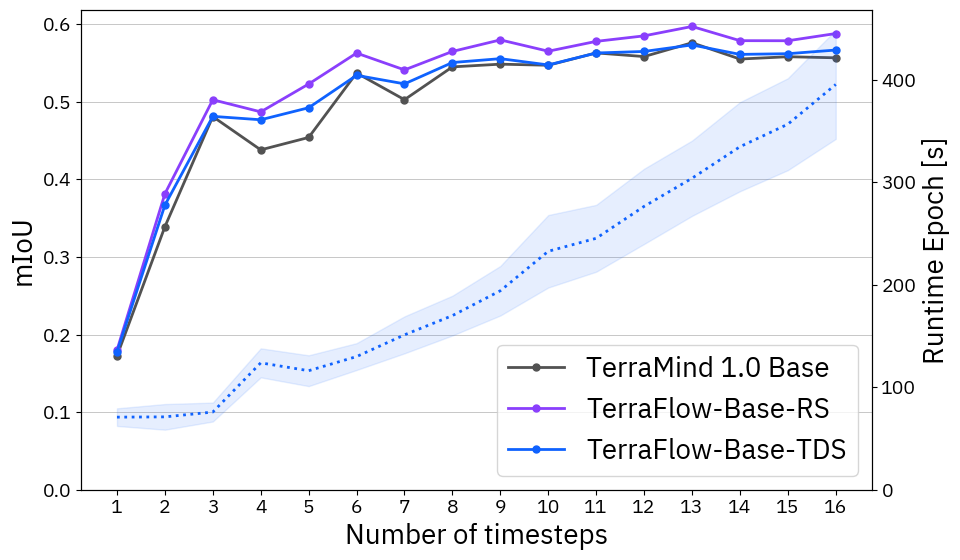

In [179]:
# PASTIS
plt.plot(pastis_times_x, pastis_values_tm_base, marker='o', label="TerraMind 1.0 Base", color=colors[2])
plt.plot(pastis_times_x, pastis_values_tf_base_rs, marker='o', label="TerraFlow-Base-RS", color=colors[1])
plt.plot(pastis_times_x, pastis_values_tf_base_tds, marker='o', label="TerraFlow-Base-TDS", color=colors[0])

plt.xlabel("Number of timesteps")
plt.ylabel("mIoU")
plt.xticks(pastis_times_x)
# plt.title("PASTIS", pad=4)
plt.legend()
plt.grid(axis='y', linewidth=0.5)
plt.ylim(bottom=0)

ax2 = plt.twinx()
ax2.plot(pastis_times_x, pastis_times_mean, color=colors[0], linestyle=':')
ax2.fill_between(pastis_times_x, pastis_times_mean - pastis_times_std, pastis_times_mean + pastis_times_std, alpha=0.1, color=colors[0])
ax2.set_ylabel("Runtime Epoch [s]")
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(f"{ROOT_DIR}/generated_images/figure_pastis_times_x_miou.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

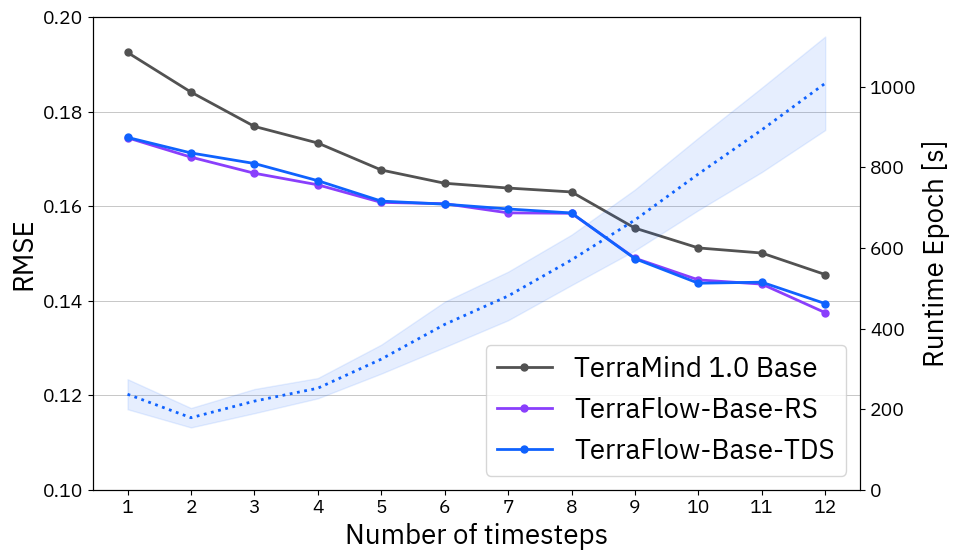

In [174]:
# BioMassters
plt.plot(bio_times_x, biomassters_values_tm_base, marker='o', label="TerraMind 1.0 Base", color=colors[2])
plt.plot(bio_times_x, biomassters_values_tf_base_rs, marker='o', label="TerraFlow-Base-RS", color=colors[1])
plt.plot(bio_times_x, biomassters_values_tf_base_tds, marker='o', label="TerraFlow-Base-TDS", color=colors[0])

plt.xlabel("Number of timesteps")
plt.ylabel("RMSE")
plt.xticks(bio_times_x)
plt.ylim(bottom=0.1, top=0.2)
plt.grid(axis='y', linewidth=0.5)
plt.legend(loc="lower right")

ax2 = plt.twinx()
ax2.plot(bio_times_x, bio_times_mean, color=colors[0], linestyle=':')
ax2.fill_between(bio_times_x, bio_times_mean - bio_times_std, bio_times_mean + bio_times_std, alpha=0.1, color=colors[0])
ax2.set_ylabel("Runtime Epoch [s]")
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(f"{ROOT_DIR}/generated_images/figure_biomassters_times_x_rmse.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

# SubSampling Strategies Plots

#

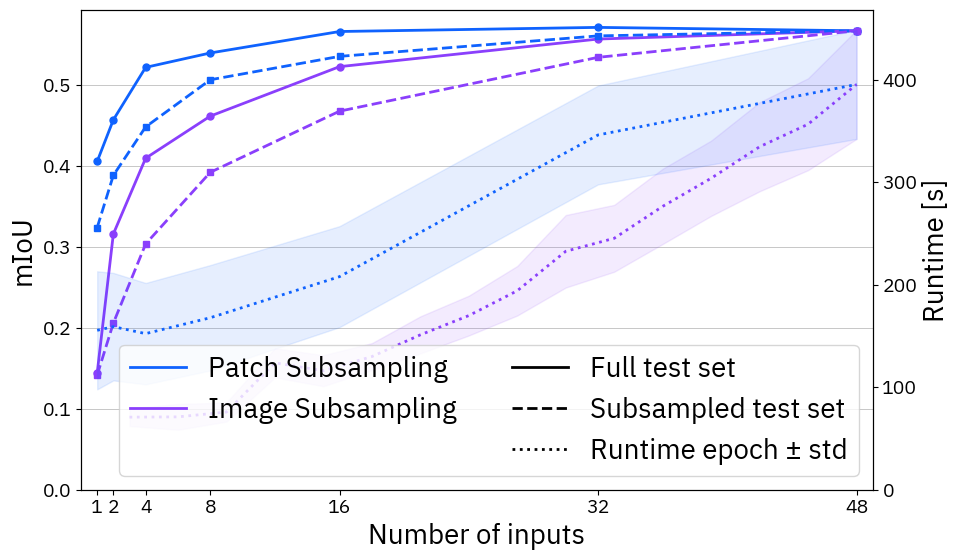

In [178]:
plt.plot(
    pastis_number_images,
    pastis_tf_base_tds_subsample,
    marker='o',
    color=colors[0],
    label="Patch Subsampling",
)

plt.plot(
    pastis_number_images,
    pastis_tf_base_tds_subimages,
    marker='o',
    color=colors[1],
    label="Image Subsampling",
)

plt.plot(
    pastis_number_images,
    pastis_tf_base_tds_subsample_testsubsample,
    marker='s',
    linestyle='--',
    color=colors[0],
    label="Patch Subsampling (Test Subsample)",
)

plt.plot(
    pastis_number_images,
    pastis_tf_base_tds_subimages_testsubsample,
    marker='s',
    linestyle='--',
    color=colors[1],
    label="Image Subsampling (Test Subsample)",
)

plt.xlabel("Number of inputs")
plt.ylabel("mIoU")

plt.xticks(pastis_number_images)
plt.ylim(bottom=0)

plt.grid(axis='y', linewidth=0.5)
# plt.legend()

ax2 = plt.twinx()
ax2.plot(pastis_times_x * 3, pastis_times_mean, color=colors[1], linestyle=':')
ax2.fill_between(pastis_times_x * 3, pastis_times_mean - pastis_times_std, pastis_times_mean + pastis_times_std, alpha=0.1, color=colors[1])
ax2.plot(pastis_number_images, pastis_subsample_mean, color=colors[0], linestyle=':')
ax2.fill_between(pastis_number_images, pastis_subsample_mean - pastis_subsample_std, pastis_subsample_mean + pastis_subsample_std, alpha=0.1, color=colors[0])
ax2.set_ylabel("Runtime [s]")
ax2.set_ylim(bottom=0)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=colors[0], linestyle='-', label='Patch Subsampling'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Image Subsampling'),
    # Line2D([0], [0], color='white', linestyle=':',  label=''),
    Line2D([], [], linestyle='none', linewidth=0, marker=None, label=''),
    Line2D([0], [0], color='k', linestyle='-',  label='Full test set'),
    Line2D([0], [0], color='k', linestyle='--', label='Subsampled test set'),
    Line2D([0], [0], color='k', linestyle=':',  label='Runtime epoch ± std'),
]

# leg = ax2.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=False)
leg = ax2.legend(handles=handles, loc='lower right', ncol=2)

plt.xlim(0, 49)

plt.tight_layout()
plt.savefig(f"{ROOT_DIR}/generated_images/figure_pastis_subsampling.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

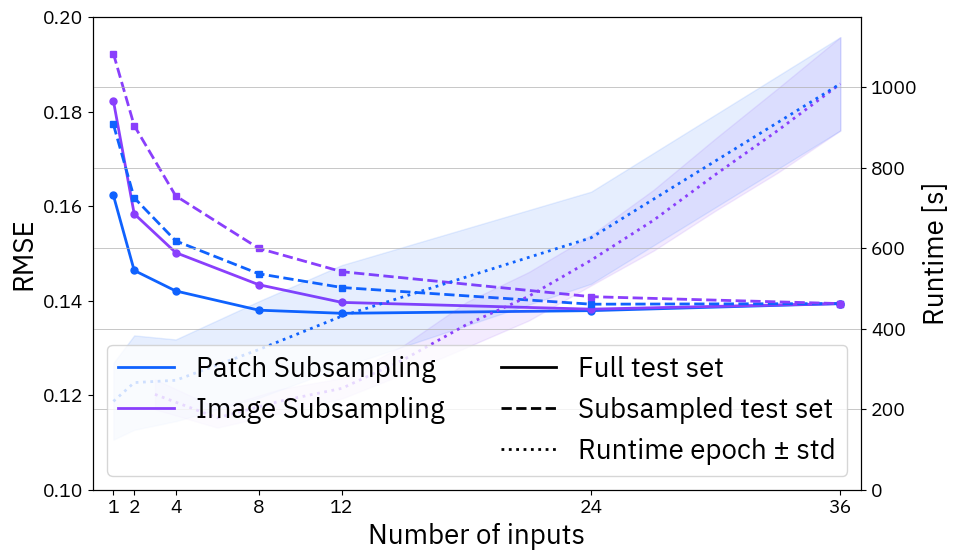

In [177]:
plt.plot(
    biomassters_number_images,
    biomassters_tf_base_tds_subsample,
    marker='o',
    color=colors[0],
    label="Patch Subsampling",
)

plt.plot(
    biomassters_number_images,
    biomassters_tf_base_tds_subimages,
    marker='o',
    color=colors[1],
    label="Image Subsampling",
)

plt.plot(
    biomassters_number_images,
    biomassters_tf_base_tds_subsample_testsubsample,
    marker='s',
    linestyle='--',
    color=colors[0],
    label="Patch Subsampling (Test Subsample)",
)

plt.plot(
    biomassters_number_images,
    biomassters_tf_base_tds_subimages_testsubsample,
    marker='s',
    linestyle='--',
    color=colors[1],
    label="Image Subsampling (Test Subsample)",
)

plt.xlabel("Number of inputs")
plt.ylabel("RMSE")
plt.ylim(bottom=0.1, top=0.2)

plt.xticks(biomassters_number_images)

ax2 = plt.twinx()
ax2.plot(bio_times_x * 3, bio_times_mean, color=colors[1], linestyle=':')
ax2.fill_between(bio_times_x * 3, bio_times_mean - bio_times_std, bio_times_mean + bio_times_std, alpha=0.1, color=colors[1])
ax2.plot(biomassters_number_images, bio_subsample_mean, color=colors[0], linestyle=':')
ax2.fill_between(biomassters_number_images, bio_subsample_mean - bio_subsample_std, bio_subsample_mean + bio_subsample_std, alpha=0.1, color=colors[0])
ax2.set_ylabel("Runtime [s]")
ax2.set_ylim(bottom=0)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=colors[0], linestyle='-', label='Patch Subsampling'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Image Subsampling'),
    # Line2D([0], [0], color='white', linestyle=':',  label=''),
    Line2D([], [], linestyle='none', linewidth=0, marker=None, label=''),
    Line2D([0], [0], color='k', linestyle='-',  label='Full test set'),
    Line2D([0], [0], color='k', linestyle='--', label='Subsampled test set'),
    Line2D([0], [0], color='k', linestyle=':',  label='Runtime epoch ± std'),
]

# leg = ax2.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=False)
leg = ax2.legend(handles=handles, loc='lower right', ncol=2)

plt.xlim(0, 37)

# plt.legend()
plt.tight_layout()
plt.grid(axis='y', linewidth=0.5)
plt.savefig(f"{ROOT_DIR}/generated_images/figure_biomassters_subsampling.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

# Running Times

# 5 Runs Comparison Standard and Subsampling

In [12]:
pastis_standard = [0.5627, 0.5640, 0.5659, 0.5660, 0.5648]
pastis_subsample = [0.5631, 0.5649, 0.5696, 0.5677, 0.5634]
biomasters_standard = [0.138722, 0.138061, 0.138284, 0.138887, 0.137652]
biomasters_subsample = [0.137245, 0.137377, 0.138292, 0.137015, 0.137241]

def mean_pm_std(x, k=1.,b=False):
    if b: return f"{k*np.mean(x):.3f} ± {k*np.std(x):.2f}"
    return f"{k*np.mean(x):.2f} ± {k*np.std(x):.2f}"

# 2x2 table
df_2x2 = pd.DataFrame(
    {
        "PASTIS": [
            mean_pm_std(pastis_standard, k=100),
            mean_pm_std(pastis_subsample, k=100),
        ],
        "BioMassters": [
            mean_pm_std(biomasters_standard, b=True),
            mean_pm_std(biomasters_subsample, b=True),
        ],
    },
    index=[
        "TerraFlow-Base-TDS",
        "TerraFlow-Base-TDS-Sub",
    ],
)

# LaTeX
print(df_2x2.to_latex())


\begin{tabular}{lll}
\toprule
 & PASTIS & BioMassters \\
\midrule
TerraFlow-Base-TDS & 56.47 ± 0.12 & 0.138 ± 0.00 \\
TerraFlow-Base-TDS-Sub & 56.57 ± 0.25 & 0.137 ± 0.00 \\
\bottomrule
\end{tabular}

